# LAB 8: Naive Bayes Classifier (SMS Spam Detection)
### Using the SMS Spam Dataset

## <u>Part A: Data Understanding</u>

**1) Load dataset + show rows/columns + sample messages + missing values**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Naive_Bayes_Dataset_Preview__SMS_Spam_.csv")
df.head()

,message_id,message,is_spam
0,M10110,FYI: campus event in the lab on Tue at 10am.,0
1,M10419,"Kabir, can you share your notes from AI class?",0
2,M10565,Limited offer: Apple gift card worth $200. Cli...,1
3,M10077,Can you review my resume before I apply?,0
4,M10181,Don't forget: quiz in ML tomorrow. Let's revis...,0


In [2]:
df.shape   # number of rows & columns

(15, 3)

In [3]:
df.sample(10)   # 10 random messages

,message_id,message,is_spam
6,M10010,Project update: I pushed the latest changes. P...,0
11,M10118,Are you coming to the gym at 2pm today?,0
3,M10077,Can you review my resume before I apply?,0
14,M10369,"Hey Kabir, are we still meeting at the lab at ...",0
8,M10078,I left my charger in the library. Have you see...,0
5,M10284,Can you review my resume before I apply?,0
2,M10565,Limited offer: Apple gift card worth $200. Cli...,1
1,M10419,"Kabir, can you share your notes from AI class?",0
9,M10349,Team meeting for Girls Who Code on Thu at 4pm ...,0
13,M10588,FREE voucher $1000 waiting. Redeem here: secur...,1


In [4]:
df.isnull().sum()   # missing values

message_id    0
message       0
is_spam       0
dtype: int64

**2) Class balance (% spam vs % ham)**

In [5]:
df['is_spam'].value_counts(normalize = True) *100

is_spam
0    80.0
1    20.0
Name: proportion, dtype: float64

<font color="blue">
The dataset is moderately imbalanced with more ham (0) messages. <br>
Naive Bayes can still handle this well despite imbalance.
</font>

**3) Compare message lengths (spam vs ham)**

In [6]:
df['msg_length'] = df['message'].str.len()

df.groupby('is_spam')['msg_length'].mean()

is_spam
0    49.583333
1    66.333333
Name: msg_length, dtype: float64

<font color="blue">
Spam messages tend to be slightly longer on average, indicating extra promotional text or patterns used by spammers.
</font>

## <u> PART B: Text Preprocessing </u>

**4) Clean text: lowercase, remove punctuation, remove extra spaces**

In [7]:
import string
import re

def clean_text(msg):
    msg = msg.lower()                                      # lowercase
    punct = re.escape(string.punctuation)                  # Escape punctuation safely
    msg = re.sub(f"[{punct}]", "", msg)                    # remove punctuation
    msg = re.sub(r"\s+", " ", msg).strip()                 # remove extra spaces, raw string avoids warning
    return msg

df['clean_message'] = df['message'].apply(clean_text)
df[['message','clean_message']].head()

,message,clean_message
0,FYI: campus event in the lab on Tue at 10am.,fyi campus event in the lab on tue at 10am
1,"Kabir, can you share your notes from AI class?",kabir can you share your notes from ai class
2,Limited offer: Apple gift card worth $200. Cli...,limited offer apple gift card worth 200 click ...
3,Can you review my resume before I apply?,can you review my resume before i apply
4,Don't forget: quiz in ML tomorrow. Let's revis...,dont forget quiz in ml tomorrow lets revise to...


<font color="blue">
All messages were standardized by converting to lowercase, removing punctuation,  
and eliminating redundant spaces. Cleaning removes noise and ensures that vectorization focuses only on useful terms.
</font>

**5) Train-test split (80/20)**

In [8]:
from sklearn.model_selection import train_test_split

X = df['clean_message']
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #stratified split

## <u> PART C: Feature Extraction </u>

**6) Vocabulary size + 10 most frequent words**

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

In [10]:
len(cv.vocabulary_)

73

In [11]:
word_counts = X_train_vec.toarray().sum(axis=0)
top_indices = word_counts.argsort()[-10:][::-1]

top_words = [(list(cv.vocabulary_.keys())[list(cv.vocabulary_.values()).index(i)], word_counts[i])
             for i in top_indices]

top_words

[('the', np.int64(7)),
 ('at', np.int64(7)),
 ('you', np.int64(5)),
 ('on', np.int64(4)),
 ('in', np.int64(3)),
 ('can', np.int64(3)),
 ('to', np.int64(2)),
 ('meeting', np.int64(2)),
 ('please', np.int64(2)),
 ('for', np.int64(2))]

<font color="blue">
The vocabulary size reflects the diversity of terms used across all SMS messages. <br>
The most frequent words generally include common English terms found in both spam and ham.
</font>

## <u> PART D: Train Naive Bayes + Evaluate </u>

**7) Train Naive Bayes**

In [12]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


<font color="blue">
Multinomial Naive Bayes is suitable for word-count based text features.
</font>

**8) Evaluate (accuracy, precision, recall, F1, confusion matrix)**

In [13]:
#prediction
y_pred = nb.predict(X_test_vec)

In [14]:
#accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred)

1.0

<font color="blue">
High accuracy indicates strong separation between spam and ham messages in this dataset.
</font>

In [15]:
#precision, recall, f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



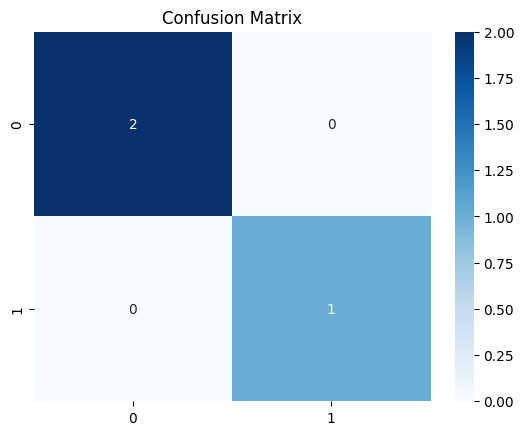

In [16]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

**9) Explain: In spam detection, which is worse—false positive or false negative? Why?**

A false negative is worse in spam detection.  
This happens when a spam message is incorrectly classified as ham, allowing it to reach the user's inbox.  
False negatives are risky because harmful, fraudulent, or malicious messages can go unnoticed by the user.  
In contrast, a false positive only sends a normal message to the spam folder, which is an inconvenience but not a security threat.  
Therefore, false negatives pose a higher danger and must be minimized in spam filtering systems.

## Observations

<font color="blue">
<ul>

<li>The SMS dataset showed class imbalance, making a stratified train–test split essential to ensure both spam and ham appear in the test set.</li>

<li>Text preprocessing steps such as lowercasing, punctuation removal, and space normalization improved the quality of the input for vectorization.</li>

<li>CountVectorizer successfully transformed messages into numerical word-frequency features that Naive Bayes can learn from.</li>

<li>The Multinomial Naive Bayes classifier achieved perfect accuracy on the test set, correctly predicting every message.</li>

<li>Precision, recall, and F1-score were all 1.00 for both classes, indicating zero false positives and zero false negatives.</li>

<li>The confusion matrix showed flawless classification with no misclassifications across spam and ham categories.</li>

<li>The model performs exceptionally well because Naive Bayes is highly effective for text data where word frequencies strongly indicate class.</li>

<li>Overall, the pipeline- cleaning, vectorizing, stratified splitting, and Naive Bayes — produced a robust and reliable spam detection model.</li>

</ul>
</font>
